In [4]:
# IMPORT DATA FROM GOOGLE DRIVE FOLDER (OPTIONAL)
# https://drive.google.com/file/d/19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8/view?usp=sharing
!gdown --id 19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8
From (redirected): https://drive.google.com/uc?id=19sj5PkEI7_L3pelBomWkW5d_Z7Tj0RV8&confirm=t&uuid=2f65d28a-f8ea-44fd-bcfc-e1836b1b79ca
To: /content/data_GOES_tp.zip
100% 755M/755M [00:11<00:00, 64.9MB/s]


In [5]:
# --
!unzip -qq data_GOES_tp.zip

In [6]:
#--
import xarray as xr

! pip install rioxarray
import rioxarray

import numpy as np
from matplotlib import pyplot as plt

import rasterio as rt
from rasterio.plot import show
from rasterio.crs import CRS
from rasterio.enums import Resampling

import os

In [7]:
# Define folder path
directory_path = '/content/drive-download-20260330T121459Z-1-001/'

# List all files in the directory
all_files = os.listdir(directory_path)

# Sort the paths
all_filles_sorted = []

for b in range(len(all_files)):
  for p in all_files:
    if int(p[20]) == (b+1):
      all_filles_sorted.append(p)

In [8]:
all_filles_sorted

['OR_ABI-L1b-RadF-M6C01_G16_s20212301400207_e20212301409515_c20212301409562.nc',
 'OR_ABI-L1b-RadF-M6C02_G16_s20212301400207_e20212301409515_c20212301409550.nc',
 'OR_ABI-L1b-RadF-M6C03_G16_s20212301400207_e20212301409515_c20212301409564.nc',
 'OR_ABI-L1b-RadF-M6C04_G16_s20212301400207_e20212301409515_c20212301409546.nc',
 'OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc',
 'OR_ABI-L1b-RadF-M6C06_G16_s20212301400207_e20212301409520_c20212301409553.nc',
 'OR_ABI-L1b-RadF-M6C07_G16_s20212301400207_e20212301409526_c20212301409569.nc']

In [43]:
# Select bounding box limits
xmin, xmax = -0.025, 0.11
ymin, ymax = 0.04, -0.15

## Bands 1-6 to reflectance and plot RGB

In [44]:
# Resample bands
def resampling_xarray(band_org, band_res):

    if band_org.rio.shape != band_res.rio.shape:
        return band_res.rio.reproject_match(
            band_org,
            resampling=Resampling.bilinear
        )
    else:
        return band_res

In [12]:
# Extract radiance data, compute reflectance and store them in a nxmxt array

listBands_refls = []
band_org = xr.open_dataset(directory_path+all_filles_sorted[0], decode_coords="all") # Set band 1 as the reference
band_org = band_org.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))

for b in range(6): # bands 1 to 6
  print(all_filles_sorted[b])
  goes_band = xr.open_dataset(directory_path+all_filles_sorted[b], decode_coords="all")
  goes_band = goes_band.sel(y=slice(ymin, ymax), x=slice(xmin, xmax))
  rad_to_ref = goes_band.Rad*goes_band.kappa0
  # Explicitly set the CRS for rad_to_ref
  rad_to_ref = rad_to_ref.rio.write_crs(goes_band.Rad.rio.crs)
  #rad_to_ref.to_netcdf(f'band{b}_res.nc')
  #print(rad_to_ref.shape)
  band_res = resampling_xarray(band_org, rad_to_ref)
  #print(band_res.shape)
  listBands_refls.append(band_res.values)

arrayBands_refls = np.array(listBands_refls)

OR_ABI-L1b-RadF-M6C01_G16_s20212301400207_e20212301409515_c20212301409562.nc
(6786, 4822)
(6786, 4822)
OR_ABI-L1b-RadF-M6C02_G16_s20212301400207_e20212301409515_c20212301409550.nc
(13571, 9643)
(6786, 4822)
OR_ABI-L1b-RadF-M6C03_G16_s20212301400207_e20212301409515_c20212301409564.nc
(6786, 4822)
(6786, 4822)
OR_ABI-L1b-RadF-M6C04_G16_s20212301400207_e20212301409515_c20212301409546.nc
(3393, 2410)
(6786, 4822)
OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc
(6786, 4822)
(6786, 4822)
OR_ABI-L1b-RadF-M6C06_G16_s20212301400207_e20212301409520_c20212301409553.nc
(3393, 2410)
(6786, 4822)


In [13]:
# Store reflectance bands in a xarray dataset
bands1to6_reflc = xr.Dataset(coords=band_org.coords, attrs=band_org.attrs)

for b in range(len(listBands_refls)):
  bands1to6_reflc[f'band{b+1}_refl'] =  xr.DataArray(arrayBands_refls[b], coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])

# OPTIONAL: visualize dataset
#bands1to6_reflc

# Compute and store pseudo-green band
bands1to6_reflc[f'bandSG_refl'] =  xr.DataArray(0.45*arrayBands_refls[1] + 0.1*arrayBands_refls[2] + 0.45*arrayBands_refls[0],
                                                coords={'y': band_org.y, 'x': band_org.x}, dims=['y', 'x'])

# OPTIONAL: visualize dataset
#bands1to6_reflc

In [39]:
# Functions to equalize and plot bands composition
def nequalize(array, p=5, nodata=0):
    if len(array.shape) == 2:
        valid = array[np.isfinite(array) & (array != nodata)]
        if valid.size == 0:
            return np.full_like(array, np.nan, dtype=float)
        vmin = np.percentile(valid, p)
        vmax = np.percentile(valid, 100 - p)
        if vmax == vmin:
            return np.zeros_like(array, dtype=float)
        eq_array = (array - vmin) / (vmax - vmin)
        eq_array[eq_array > 1] = 1
        eq_array[eq_array < 0] = 0

        return eq_array

    elif len(array.shape) == 3:
        eq_array = np.empty_like(array, dtype=float)
        for i in range(array.shape[0]):
            eq_array[i] = nequalize(array[i], p=p, nodata=nodata)

        return eq_array

# def plot_rgb(array, band_list , p = 0, nodata = None, figsize = (12,6), title = None):
def plot_rgb(array, p = 0, nodata = None, figsize = (12,6), title = None):
    '''
    Esta función toma como parámetros de entrada la matriz a ser ploteada,
    una lista de índices correspondientes a las bandas que queremos usar,
    en el orden que deben estar (ej: [1,2,3]), y un parámetro p que es opcional
    que es el percentil de equalización.

    Por defecto tambien asigna un tamaño de figura en (12,6), que también puede ser modificado.

    Devuelve solamente un ploteo, no modifica el arreglo original.
    Nota: array debe ser una matriz con estas dimensiones de entrada: [bandas, filas, columnas]
    '''
    #if not title:
    #    title = f'Combinación {band_list} \n (percentil {p}%)'

    img = nequalize(array, p=p, nodata=nodata)
    plt.figure(figsize = figsize)
    plt.title(title , size = 20)
    show(img)
    plt.show()

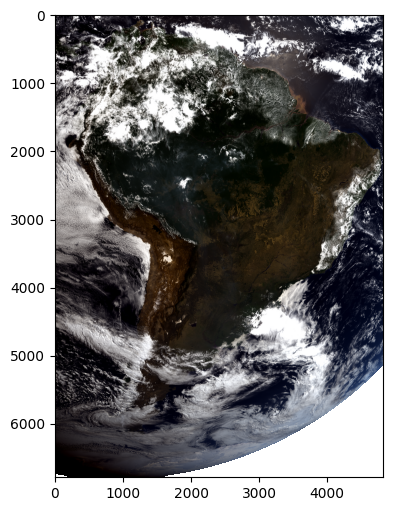

In [46]:
# Extract bands data and plot
band_r = bands1to6_reflc.band2_refl.values
band_g = bands1to6_reflc.bandSG_refl.values
band_b = bands1to6_reflc.band1_refl.values

## Store bands values in a single array
array = np.array([band_r, band_g, band_b])

## Plot bands composition
plot_rgb(array, p = 5)

In [ ]:
#bands1to6_reflc
bands1to6_reflc.to_netcdf('bands1to6_reflc.nc')

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: SerializationWarning: saving variable y with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)
/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: SerializationWarning: saving variable x with floating point data as an integer dtype without any _FillValue to use for NaNs
  exec(code_obj, self.user_global_ns, self.user_ns)


## Band 7 to bright temperature

In [ ]:
print(all_files[6])
goes_band7 = xr.open_dataset(directory_path+all_files[6], decode_coords="all")

OR_ABI-L1b-RadF-M6C05_G16_s20212301400207_e20212301409515_c20212301409558.nc


In [ ]:
goes_band7

<xarray.Dataset> Size: 942MB
Dimensions:                                           (y: 10848, x: 10848,
                                                       number_of_image_bounds: 2,
                                                       num_star_looks: 24,
                                                       number_of_time_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 43kB 0.1519...
  * x                                                 (x) float32 43kB -0.151...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    band_id                                           (band) int8 1B ...
    band_wavelength                                   (band) float32 4B ...
    t                                                 datetime64[ns] 8B ...
    goes_imager_projection                            int32 4B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_image_bounds, num_star_looks,
                                number_of_time_bounds, band
Data variables: (12/35)
    Rad                                               (y, x) float32 471MB ...
    DQF                                               (y, x) float32 471MB ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat                    float32 4B ...
    nominal_satellite_subpoint_lon                    float32 4B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            int32 4B ...
    processing_parm_version_container                 int32 4B ...
    algorithm_product_version_container               int32 4B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2021-08-18T14:09:55.8Z
    time_coverage_start:       2021-08-18T14:00:20.7Z
    time_coverage_end:         2021-08-18T14:09:51.5Z
    LUT_Filenames:             SpaceLookParams(FM1A_CDRL79RevP_PR_09_00_02)-6...
    id:                        f9451063-446b-4689-afbb-87b9146b5ec6

In [ ]:
goes_band7.planck_fk1.values

array(nan, dtype=float32)

In [ ]:
xr.DataArray(new_band_data_1, coords=source_ds.coords, dims=source_ds['band_name_from_source'].dims)

In [ ]:
data_plot = (goes_band.Rad*goes_band.kappa0)

In [ ]:
fig, ax = plt.subplots()

ax.imshow(data_plot)

NameError: name 'plt' is not defined

In [ ]:
band_setCRS = goes_band.rio.write_crs(src_crs, inplace=True)

In [ ]:
data_plot = (goes_band.Rad*goes_band.kappa0)

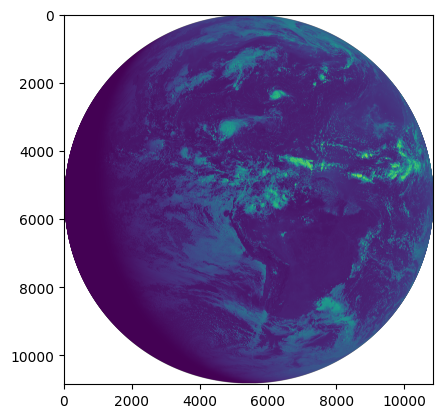

In [ ]:
fig, ax = plt.subplots()

ax.imshow(data_plot)

In [ ]:
list_kappa_1to6 = []

src_crs = CRS.from_authority("ESRI", "102497")

for b in all_files:

  goes_band = xr.open_dataset(directory_path+all_files[0], decode_coords="all")
  #goes_band
  band_setCRS = goes_band.rio.write_crs(src_crs, inplace=True)




<xarray.Dataset> Size: 942MB
Dimensions:                                           (y: 10848, x: 10848,
                                                       number_of_image_bounds: 2,
                                                       num_star_looks: 24,
                                                       number_of_time_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 43kB 0.1519...
  * x                                                 (x) float32 43kB -0.151...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    band_id                                           (band) int8 1B ...
    band_wavelength                                   (band) float32 4B ...
    t                                                 datetime64[ns] 8B ...
    goes_imager_projection                            int32 4B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_image_bounds, num_star_looks,
                                number_of_time_bounds, band
Data variables: (12/35)
    Rad                                               (y, x) float32 471MB ...
    DQF                                               (y, x) float32 471MB ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat                    float32 4B ...
    nominal_satellite_subpoint_lon                    float32 4B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            int32 4B ...
    processing_parm_version_container                 int32 4B ...
    algorithm_product_version_container               int32 4B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2021-08-18T14:09:56.2Z
    time_coverage_start:       2021-08-18T14:00:20.7Z
    time_coverage_end:         2021-08-18T14:09:51.5Z
    LUT_Filenames:             SpaceLookParams(FM1A_CDRL79RevP_PR_09_00_02)-6...
    id:                        694ade65-94ac-4ea5-a8dc-4667e917a3fb

In [ ]:
goes_band.kappa0.values

array(0.0015955, dtype=float32)

In [ ]:
goes_band

<xarray.Dataset> Size: 942MB
Dimensions:                                           (y: 10848, x: 10848,
                                                       number_of_image_bounds: 2,
                                                       num_star_looks: 24,
                                                       number_of_time_bounds: 2,
                                                       band: 1)
Coordinates:
  * y                                                 (y) float32 43kB 0.1519...
  * x                                                 (x) float32 43kB -0.151...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    time_bounds                                       (number_of_time_bounds) datetime64[ns] 16B ...
    band_id                                           (band) int8 1B ...
    band_wavelength                                   (band) float32 4B ...
    t                                                 datetime64[ns] 8B ...
    goes_imager_projection                            int32 4B ...
    y_image                                           float32 4B ...
    x_image                                           float32 4B ...
Dimensions without coordinates: number_of_image_bounds, num_star_looks,
                                number_of_time_bounds, band
Data variables: (12/35)
    Rad                                               (y, x) float32 471MB ...
    DQF                                               (y, x) float32 471MB ...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat                    float32 4B ...
    nominal_satellite_subpoint_lon                    float32 4B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            int32 4B ...
    processing_parm_version_container                 int32 4B ...
    algorithm_product_version_container               int32 4B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2021-08-18T14:09:56.2Z
    time_coverage_start:       2021-08-18T14:00:20.7Z
    time_coverage_end:         2021-08-18T14:09:51.5Z
    LUT_Filenames:             SpaceLookParams(FM1A_CDRL79RevP_PR_09_00_02)-6...
    id:                        694ade65-94ac-4ea5-a8dc-4667e917a3fb

In [ ]:
goes_band = xr.open_dataset(directory_path+all_files[0], decode_coords="all")

src_crs = CRS.from_authority("ESRI", "102497")
goes_test = goes_test.rio.write_crs(src_crs, inplace=True)



In [ ]:
src_crs = CRS.from_authority("ESRI", "102497")
goes_test = goes_test.rio.write_crs(src_crs, inplace=True)

# Verify source CRS was applied
#print("Source CRS:", goes_test.rio.crs)

Source CRS: ESRI:102497


In [ ]:
band = goes_test.Rad

In [ ]:
output_path = "goes_band.tif"

band.rio.to_raster(
    output_path,
    driver="GTiff",
    dtype="float32",
    compress="LZW",            # lossless compression, reduces file size ~3–5x
    tiled=True,                # tiled layout = faster spatial reads
    windowed=True,             # write in chunks (safe for large arrays)
)

In [ ]:
band_plot = rt.open("/content/goes_band.tif").read()[0]

In [ ]:
import matplotlib.pyplot as plt
#
#fig, ax = plt.subplots()

#ax.imshow(band_plot)

In [ ]:
# ── 3. Reproject to EPSG:4326 ────────────────────────────────────────────────
ds_reproj = goes_test.rio.reproject(
    "EPSG:4326",
    resampling=Resampling.bilinear,  # or nearest, cubic, lanczos, etc.
)
#print("Target CRS:", ds_reproj.rio.crs)
#print(ds_reproj)

Target CRS: EPSG:4326
<xarray.Dataset> Size: 942MB
Dimensions:                                           (x: 10812, y: 10884,
                                                       number_of_image_bounds: 2,
                                                       num_star_looks: 24)
Coordinates:
  * x                                                 (x) float64 86kB -75.0 ...
  * y                                                 (y) float64 87kB 1.373e...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    x_image                                           float32 4B 0.0
    y_image                                           float32 4B 0.0
    t                                                 datetime64[ns] 8B 2021-...
    goes_imager_projection                            int64 8B 0
Dimensions without coordinates: number_of_image_bounds, num_star_looks
Data 

In [ ]:
ds_reproj

<xarray.Dataset> Size: 942MB
Dimensions:                                           (x: 10812, y: 10884,
                                                       number_of_image_bounds: 2,
                                                       num_star_looks: 24)
Coordinates:
  * x                                                 (x) float64 86kB -75.0 ...
  * y                                                 (y) float64 87kB 1.373e...
    t_star_look                                       (num_star_looks) datetime64[ns] 192B ...
    band_wavelength_star_look                         (num_star_looks) float32 96B ...
    x_image                                           float32 4B 0.0
    y_image                                           float32 4B 0.0
    t                                                 datetime64[ns] 8B 2021-...
    goes_imager_projection                            int64 8B 0
Dimensions without coordinates: number_of_image_bounds, num_star_looks
Data variables: (12/35)
    Rad                                               (y, x) float32 471MB na...
    DQF                                               (y, x) float32 471MB na...
    y_image_bounds                                    (number_of_image_bounds) float32 8B ...
    x_image_bounds                                    (number_of_image_bounds) float32 8B ...
    nominal_satellite_subpoint_lat                    float32 4B ...
    nominal_satellite_subpoint_lon                    float32 4B ...
    ...                                                ...
    algorithm_dynamic_input_data_container            int32 4B ...
    processing_parm_version_container                 int32 4B ...
    algorithm_product_version_container               int32 4B ...
    star_id                                           (num_star_looks) float32 96B ...
    channel_integration_time                          float64 8B ...
    channel_gain_field                                float64 8B ...
Attributes: (12/30)
    naming_authority:          gov.nesdis.noaa
    Conventions:               CF-1.7
    standard_name_vocabulary:  CF Standard Name Table (v35, 20 July 2016)
    institution:               DOC/NOAA/NESDIS > U.S. Department of Commerce,...
    project:                   GOES
    production_site:           WCDAS
    ...                        ...
    timeline_id:               ABI Mode 6
    date_created:              2021-08-18T14:09:56.2Z
    time_coverage_start:       2021-08-18T14:00:20.7Z
    time_coverage_end:         2021-08-18T14:09:51.5Z
    LUT_Filenames:             SpaceLookParams(FM1A_CDRL79RevP_PR_09_00_02)-6...
    id:                        694ade65-94ac-4ea5-a8dc-4667e917a3fb

In [ ]:
ds_reproj.Rad.plot()